# BEE 4750 Lab 2: Monte Carlo

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [2]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `c:\Users\Donny\OneDrive\Post-Grad\Courses\BEE 5750\Lab 2\lab-2-dc2266`


In [3]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting

## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [4]:
Random.seed!(1)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [5]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 1
 3
 5
 4
 6
 2
 5
 5
 5
 2
 ⋮
 3
 6
 5
 5
 6
 3
 6
 6
 6

And then we can plot a histogram of these rolls:

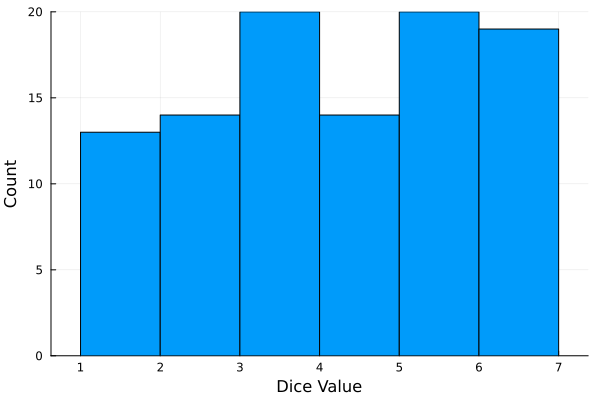

In [6]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

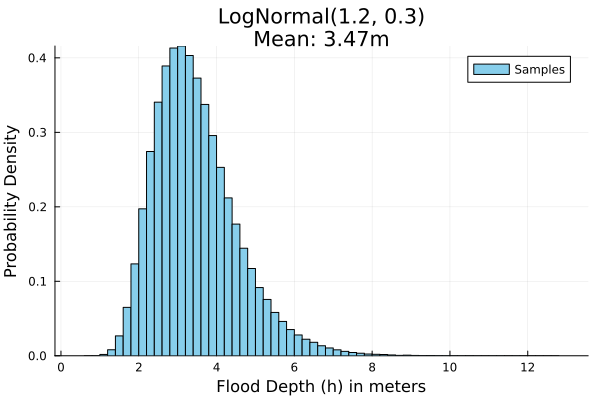

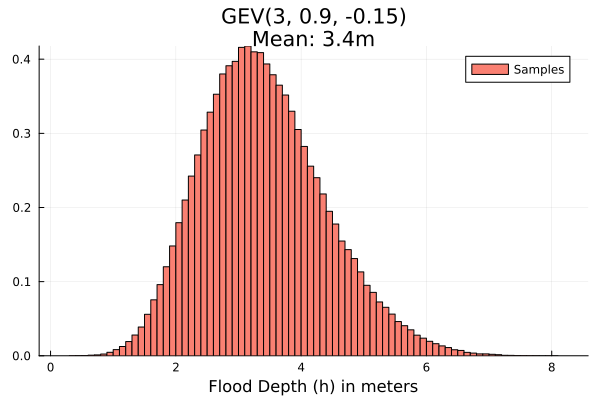

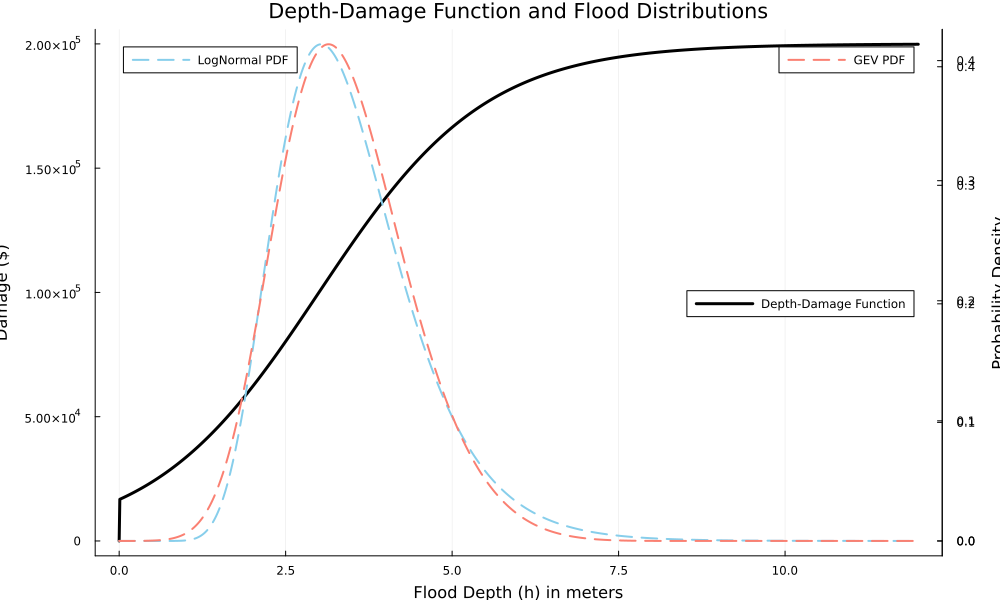

Sample Size for each distribution: 300000

LogNormal Distribution
Estimated Expected Annual Damage: $115161.82793242997
Estimated 99% Quantile of Damage: $190093.10599905954

Generalized Extreme Value (GEV) Distribution
Estimated Expected Annual Damage: $113501.10716210285
Estimated 99% Quantile of Damage: $183097.87137089134



In [21]:
# define constants
const L = 200_000.0  # Maximum loss in USD (using Float64)
const k = 0.8        # Slope
const h0 = 3.0       # Inflection point
const SAMPLE_SIZE = 300_000

# defining the depth-damage function
"""
    depth_damage_function(h)

Calculates the economic damage for a given flood depth `h` using a
bounded logistic function. Damage is zero for h <= 0.
"""
function depth_damage_function(h::Real)
    if h <= 0
        return 0.0
    end
    return L / (1 + exp(-k * (h - h0)))
end

# create flood depth distribution samples

# lognormal distribution with mean and stddev determined
lognormal_dist = LogNormal(1.2, 0.3)
# GEV distribution with location, scale, shape determined
gev_dist = GeneralizedExtremeValue(3.0, 0.9, -0.15)

# generate random samples
h_lognormal = rand(lognormal_dist, SAMPLE_SIZE)
h_gev = rand(gev_dist, SAMPLE_SIZE)

# create histograms of flood depth distributions

p1 = histogram(h_lognormal,
    bins=100,
    normalize=:pdf,
    label="Samples",
    title="LogNormal(1.2, 0.3)\nMean: $(round(mean(h_lognormal), digits=2))m",
    xlabel="Flood Depth (h) in meters",
    ylabel="Probability Density",
    color=:skyblue,
    legend=:topright
)
display(p1)

p2 = histogram(h_gev,
    bins=100,
    normalize=:pdf,
    label="Samples",
    title="GEV(3, 0.9, -0.15)\nMean: $(round(mean(h_gev), digits=2))m",
    xlabel="Flood Depth (h) in meters",
    color=:salmon,
    legend=:topright
)
display(p2)


# monte carlo simulation of damages

# distributing flood depths through the depth-damage function
damage_lognormal = depth_damage_function.(h_lognormal)
damage_gev = depth_damage_function.(h_gev)

# finding data requested
# expected value of damage
expected_damage_ln = mean(damage_lognormal)
expected_damage_gev = mean(damage_gev)

# 99% quantile of damage
quantile_99_ln = quantile(damage_lognormal, 0.99)
quantile_99_gev = quantile(damage_gev, 0.99)

# print results
println("Sample Size for each distribution: ", SAMPLE_SIZE, "\n")

println("LogNormal Distribution")
println("Estimated Expected Annual Damage: \$", expected_damage_ln)
println("Estimated 99% Quantile of Damage: \$", quantile_99_ln, "\n")

println("Generalized Extreme Value (GEV) Distribution")
println("Estimated Expected Annual Damage: \$", expected_damage_gev)
println("Estimated 99% Quantile of Damage: \$", quantile_99_gev, "\n")


# --- 7. Explain Differences with a Combined Plot ---

# Create a range of h values for plotting the functions
h_vals = 0:0.01:12
damage_vals = depth_damage_function.(h_vals)
pdf_lognormal = pdf.(lognormal_dist, h_vals)
pdf_gev = pdf.(gev_dist, h_vals)

# Create the plot with a secondary y-axis
plot(h_vals, damage_vals,
    label="Depth-Damage Function",
    xlabel="Flood Depth (h) in meters",
    ylabel="Damage (\$)",
    color=:black,
    lw=3,
    legend=:right,
    size=(1000, 600),
    title="Depth-Damage Function and Flood Distributions"
)

# Plot PDFs on the secondary axis
plot!(twinx(), h_vals, pdf_lognormal,
    label="LogNormal PDF",
    ylabel="Probability Density",
    color=:skyblue,
    linestyle=:dash,
    lw=2,
    legend=:topleft
)
plot!(twinx(), h_vals, pdf_gev,
    label="GEV PDF",
    color=:salmon,
    linestyle=:dash,
    lw=2
) |> display


1. The amount of sample is decided by progressively increasing the sample size. In this case, I started from 10,000 samples and ends at 300,000 samples. The point where I decide to stop is when the histogram has started to smoothen, which indicates consistency and higher accuracy. As figure 1 and 2 shows, there is no bump in the bell distribution, while at 200,000 samples, there is still a bump. Going for more samples at this point will also increase accuracy, but will be insignificant relative to the increases from 10,000 to 300,000 samples.
2. There is almost no difference for both distribution as they have a similar mean. This infers the data distribution is similar. However, it differs in the sense of the type of distribution. The lognormal acknolwedges no limit, this means it will account even the most impossible of flood depth into its calculation, while GEV has an upper limit based on a predetermined formula using parameters set. This way, the 99% quantile damage of log will always be higher because it also account all possible (even if it is remote) flood.
3. I will use the lognormal distribution if I want to estimate for extreme cases. This is due to the sample size of lognormal that is larger than GEV, giving a stronger representation for extreme cases. However, if I want to measure impact from floods within the mean or mode, I will use GEV as it has a more balanced distribution as can be seen in the curve. This also applies by looking into the historical data, whether the historical data fits better into the GEV model or lognormal model. By looking back into the trend, we can forecast better.

## References

LLM was consulted in this work. The following ways I used LLM are as follows
1. To understand the formula behind the lognormal and the GEV. This way, I can understand the logic behind the calculation and how to interpret the elements
2. To construct the code logic of implementing monte carlo, from determining random samples, distributing to the equation, to pulling the quant 99% number in the samples determined